In [1]:
# TO DO : 

# Check if Negative binomial is still the right distribution (shapiro-wilk test?)
# Check if hypothesis of Negative binomial holds on a p-value  (hypothesis test)

In [1]:
# The required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import nbinom
sns.set_theme()

In [2]:
# The storms dataframe :
df = pd.read_csv('atlantic_storms.csv',header=0)
df['year'] = pd.DatetimeIndex(df['date']).year
display(df)

,index,id,name,date,record_identifier,status_of_system,latitude,longitude,maximum_sustained_wind_knots,maximum_pressure,...,34_kt_nw,50_kt_ne,50_kt_se,50_kt_sw,50_kt_nw,64_kt_ne,64_kt_se,64_kt_sw,64_kt_nw,year
0,0,AL011851,UNNAMED,1851-06-25 00:00:00,NaN,HU,28.0,-94.8,80,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1851
1,1,AL011851,UNNAMED,1851-06-25 06:00:00,NaN,HU,28.0,-95.4,80,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1851
2,2,AL011851,UNNAMED,1851-06-25 12:00:00,NaN,HU,28.0,-96.0,80,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1851
3,3,AL011851,UNNAMED,1851-06-25 18:00:00,NaN,HU,28.1,-96.5,80,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1851
4,4,AL011851,UNNAMED,1851-06-25 21:00:00,L,HU,28.2,-96.8,80,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1851
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52686,52686,AL302020,THETA,2020-11-15 12:00:00,NaN,LO,31.4,-18.3,30,1009.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2020
52687,52687,AL302020,THETA,2020-11-15 18:00:00,NaN,LO,31.6,-18.0,30,1012.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2020
52688,52688,AL302020,THETA,2020-11-16 00:00:00,NaN,LO,32.1,-17.9,30,1013.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2020
52689,52689,AL302020,THETA,2020-11-16 06:00:00,NaN,LO,32.7,-18.2,25,1014.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2020


In [3]:
# Let's isolate our years :
df2 = df.drop_duplicates(subset=["id"],keep ='first')  # drop multiple "years".
df2 = df2.loc[:,df2.columns.isin(['year'])]            # drop all other un-necessary columns.
df2 = df2.reset_index(drop = False)
display(df2)

,index,year
0,0,1851
1,14,1851
2,15,1851
3,16,1851
4,65,1851
...,...,...
1918,52503,2020
1919,52534,2020
1920,52575,2020
1921,52600,2020


In [4]:
df3 = pd.DataFrame()
df3['counts'] = df2.year.value_counts()
df3['years'] = df3.index.to_series()
df3.sort_values(by=['years'])

df3.sort_values(by=['years'], inplace = True)

y = df3['counts'].to_numpy()
x = df3['years'].to_numpy()
display(df3)

,counts,years
year,,
1851,6,1851
1852,5,1852
1853,8,1853
1854,5,1854
1855,5,1855
...,...,...
2016,16,2016
2017,18,2017
2018,16,2018


Text(0.5, 0, 'Year')

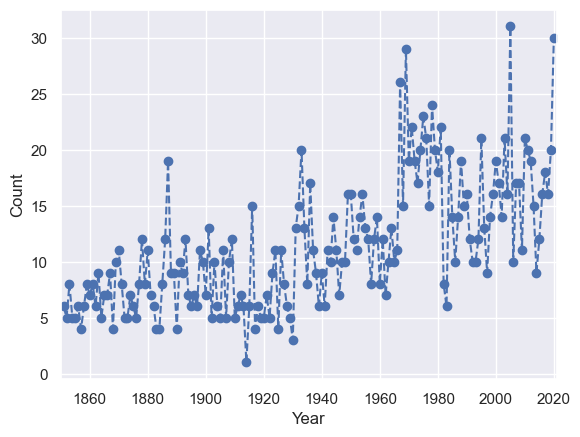

In [5]:
# The years of interest :
min_year = 1850
max_year = 2021

fig0, ax0 = plt.subplots()

ax0.plot(x,y,'bo--')
plt.xlim(min_year,max_year)
ax0.set_ylabel('Count')
ax0.set_xlabel('Year')

In [6]:
df4 = df3[df3.years > min_year-1]
df4 = df4[df4.years <=max_year]
df4 = pd.DataFrame(df4)
hurr_res = df4.counts.to_numpy()
display(df4)

,counts,years
year,,
1851,6,1851
1852,5,1852
1853,8,1853
1854,5,1854
1855,5,1855
...,...,...
2016,16,2016
2017,18,2017
2018,16,2018


In [7]:
df5 = pd.DataFrame(df4.counts.value_counts())
df5.rename(columns={'count':'observations'}, inplace = True)
df5 = df5.reindex(index = np.delete(np.arange(df5.index.max() + 1),0), fill_value = 0) #new array, deleting 0 from the array
df5['hurr_qty'] = df5.index.to_series()
df5

,observations,hurr_qty
counts,,
1,1,1
2,0,2
3,1,3
4,7,4
5,15,5
6,17,6
7,12,7
8,12,8
9,10,9


[ 1  0  1  7 15 17 12 12 10 14 12 11  6  7  6  8  5  2  6  6  4  2  1  1
  0  1  0  0  1  1  1]
170
172
[0.00581395 0.         0.00581395 0.04069767 0.0872093  0.09883721
 0.06976744 0.06976744 0.05813953 0.08139535 0.06976744 0.06395349
 0.03488372 0.04069767 0.03488372 0.04651163 0.02906977 0.01162791
 0.03488372 0.03488372 0.02325581 0.01162791 0.00581395 0.00581395
 0.         0.00581395 0.         0.         0.00581395 0.00581395
 0.00581395]


<BarContainer object of 31 artists>

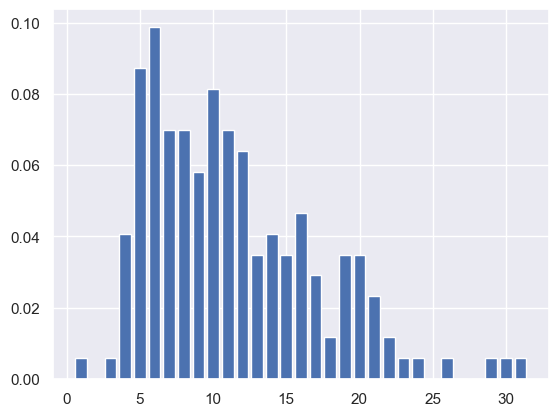

In [8]:
# Number of hurricanes per year : 
hurr_freq = df5['observations'].to_numpy()
print(hurr_freq)
# Total amount of hurricanes in the number of years : 
total_obs = hurr_freq.sum()
total_years = max_year-(min_year-1)
print(total_obs)
print(total_years)

# Annual probability per number of hurricane :
hurr_prob = hurr_freq / total_years
print(hurr_prob)
# Note : hurr_prob sums to 1. 

# Plotted : 
bins = max(df4['counts'])
n_bins = np.linspace(1,bins,bins)
plt.bar(n_bins,hurr_prob)

The bins edges are : 
 [ 2.9999    5.799911  8.599922 11.399933 14.199944 16.999955 19.799966
 22.599977 25.399988 28.199999 31.00001 ]
The PDF values are : 
 [0.04775729 0.08513256 0.07475054 0.04983369 0.02906965 0.02699325
 0.02491685 0.00415281 0.0020764  0.00622921]


(0.0, 33.00001)

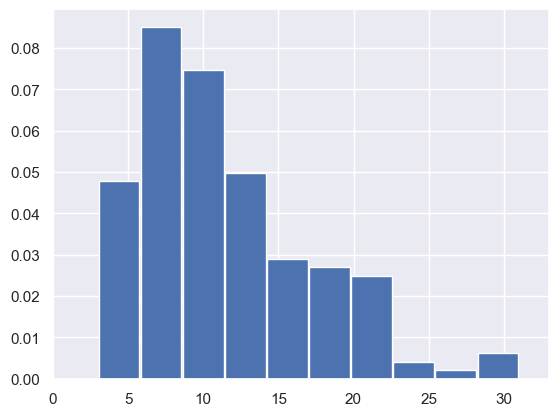

In [9]:
start_bin = 2.9999
end_final_bin = 31.00001 # include a .00001 to ensure the final bin does not exclude the last value.
nb_bins_req = 10

# The bins :
bins2 = np.linspace(start_bin,end_final_bin,nb_bins_req+1) # start, stop & n+1 bins required

bin_width = bins2[1]-bins2[0] # Width of a bin
bins3 = np.linspace((start_bin+bin_width/2),(end_final_bin-bin_width/2),nb_bins_req) #

# The observations : 
obs = df4['counts'].to_numpy()
binned_obs = pd.cut(obs, bins= bins2, include_lowest = True, right = False).value_counts().to_numpy()
hurr_PDF_per_bin = binned_obs/total_years/bin_width # CDF of each bin

# Summary
print('The bins edges are : \n',bins2)
print('The PDF values are : \n',hurr_PDF_per_bin) 

fig, ax = plt.subplots()

ax.bar(bins3,hurr_PDF_per_bin, width = bin_width-0.1)
plt.xlim(0,end_final_bin+2)

In [10]:
# Fitting to negative binomial : 
data = df4.iloc[:,0].to_numpy()
mean = data.mean()
#var = data.var(ddof = 1)
var = data.var(ddof = 1)
sd = var**0.5

pd.DataFrame(hurr_freq).to_csv('test_data2.csv')



# Parameters of the distribution :
p_calc = mean/var
n_calc = (mean**2)/(var-mean)


print(f'The mean equals to {mean:.5f} \nThe variance equals to : {var:.5f} \nThe standard deviation equals to : {sd:.5f}')
print(f'p equals to : {p_calc:.5f} \nn equals to : {n_calc:.5f}')

The mean equals to 11.31176 
The variance equals to : 33.23359 
The standard deviation equals to : 5.76486
p equals to : 0.34037 
n equals to : 5.83692


In [11]:
r1 = mean**2/(var-mean)
print(r1)

p1 = 1-mean/var
print(p1)

27.72767724253237
0.3748709934243504


In [13]:
# Putting the numbers into action : 

# Generate sample data
n_test = mean**2/(var-mean)
p_test = mean/var
sample = nbinom.rvs(n=n_test, p=p_test, size=10000)

# Estimate parameters
mu = np.mean(sample)  # Mean
sigma_sqr = np.var(sample)  # Variance

# Convert mean and variance to n, p parameterization
n_est = mu**2 / (sigma_sqr - mu)
p_est = mu / sigma_sqr

# Print results
print("""
                   {:<3}   {:<3}
True parameters:  {:<3}   {:<3}
Estimates      :  {:<3}   {:<3}""".format('n', 'p', n_test, p_test,
                                  np.round(n_est, 5), np.round(p_est, 5)))


                   n     p  
True parameters:  27.72767724253237   0.6251290065756496
Estimates      :  26.63041   0.61587


In [12]:
# Exporting to a nice excel : 
params = (pd.DataFrame([[n_calc],[p_calc]]).T)
params.columns = ['n','p']          
params.to_excel('genesis_params.xlsx', index = False)

## Some visualizations :

[0.         0.03846154 0.17307692 0.32692308 0.48076923 0.69230769
 0.90384615 0.94230769 0.94230769 0.98076923]


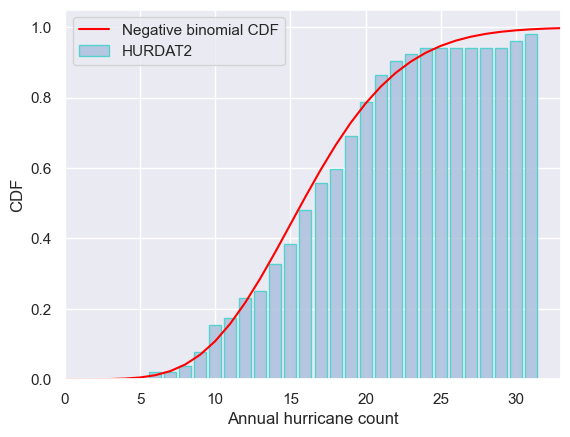

In [16]:
# CDF graph : 
x_plot = np.linspace(0,40,41)
generic_data = nbinom.pmf(x_plot,n_calc,p_calc)

cdf = np.cumsum(hurr_PDF_per_bin)*bin_width
cdf1 = np.cumsum(hurr_prob)



generic_cdf = np.cumsum(generic_data)


# plotting  CDF

plt.bar(n_bins, cdf1, label="HURDAT2", color = 'lightsteelblue',alpha = 0.9, edgecolor = "mediumturquoise")
plt.plot(x_plot, generic_cdf, color="red", label="Negative binomial CDF")
plt.xlim(0,end_final_bin+2)
plt.xlabel('Annual hurricane count')
plt.ylabel('CDF')
plt.legend()

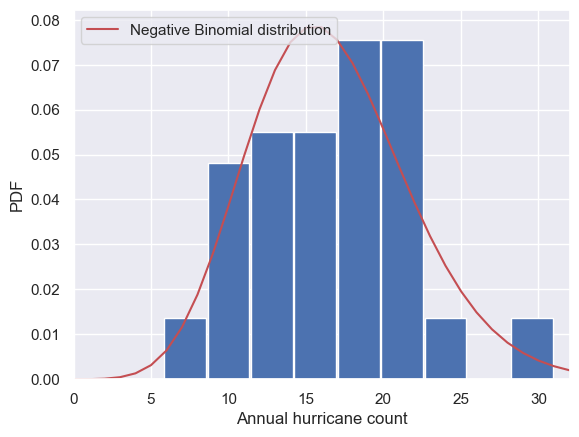

In [17]:
# PDF graph
fig, ax = plt.subplots()
ax.bar(bins3,hurr_PDF_per_bin, width = bin_width-0.1)
ax.plot(x_plot,nbinom.pmf(x_plot,n_calc,p_calc),'r-',lw=1.5,label = 'Negative Binomial distribution')
plt.xlim(0,end_final_bin+1)
ax.set_ylabel('PDF')
ax.set_xlabel('Annual hurricane count')
leg = ax.legend()